# Data I/O Utilities for DSP & Sonar

**Why standard data I/O utilities?**
- Easy, reproducible reading and writing of real-world and test signals
- Quick switching between audio, array, and text formats for analysis, demo, or ML
- Makes your workflow robust and shareable

**Common formats:** WAV (audio), CSV/TXT (table/array), NPY (NumPy binary)

---


In [1]:
import numpy as np
from scipy.io import wavfile
import csv
import matplotlib.pyplot as plt
# WAV audio
def read_wav(filename):
    fs, data = wavfile.read(filename)
    return fs, data

def write_wav(filename, data, fs):
    wavfile.write(filename, fs, data.astype(np.int16))

# CSV
def read_csv(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        return np.array([list(map(float, row)) for row in reader])

def write_csv(filename, array):
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(array)

# NPY
def read_npy(filename):
    return np.load(filename)

def write_npy(filename, array):
    np.save(filename, array)


### Demo: Save and Load a Numpy Array

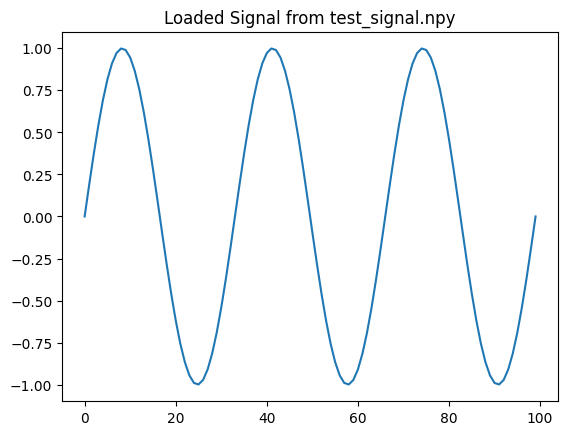

In [2]:
arr = np.sin(2*np.pi*3*np.linspace(0,1,100))
write_npy('test_signal.npy', arr)
arr2 = read_npy('test_signal.npy')
plt.plot(arr2)
plt.title('Loaded Signal from test_signal.npy')
plt.show()


### Demo: Save and Load Array as CSV

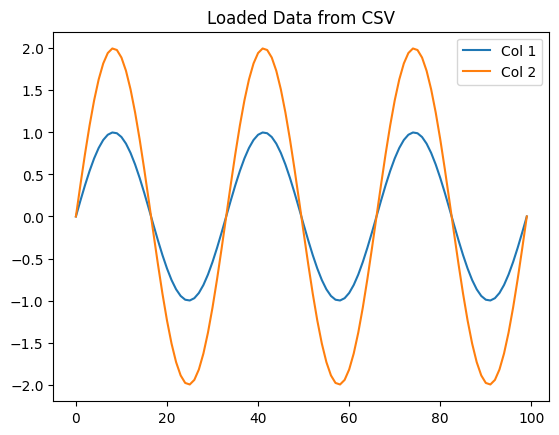

In [4]:
array2d = np.column_stack([arr, arr*2])
write_csv('test_signal.csv', array2d)
arr2d_loaded = read_csv('test_signal.csv')
plt.plot(arr2d_loaded[:,0], label='Col 1')
plt.plot(arr2d_loaded[:,1], label='Col 2')
plt.title('Loaded Data from CSV')
plt.legend()
plt.show()


---
**Usage Tips:**  
- Use WAV for audio/sonar signals you want to hear or process in audio tools.
- Use NPY for fast, lossless NumPy array saving (preferred for large/simulated data).
- Use CSV for sharing tables, small arrays, or signals with non-Python tools.

**Update the file paths as needed for your platform.**
